In [103]:
import pandas as pd
import numpy as np

In [104]:
df = pd.read_excel("Exploratory Data Analysis.xlsx",sheet_name="Raw_Data")
df_clean = pd.read_excel('Exploratory Data Analysis.xlsx',sheet_name="Cleaned_Data")

In [105]:
df.tail()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Duplicate_Check,Missing_Check,Date_Check,Precision_Check
1198,ORD201198,2024-08-22,C64753,Chair,4.000000000,262.520000000,509 Main St,Debit Card,Cancelled,TRK71683331,4.000000000,WINTER15,Instagram,1050.080000000,Unique,OK,OK,OK
1199,ORD201199,2023-06-11,C57502,Tablet,4.000000000,560.580000000,201 Main St,Gift Card,Returned,TRK51116746,6.000000000,SAVE10,Referral,2242.320000000,Unique,OK,OK,OK
1200,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1201,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,TOTAL ISSUES FOUND:,309,NaN,NaN,NaN
1202,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,STATUS:,NEEDS REVIEW,NaN,NaN,NaN


In [106]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,Duplicate_Check,Missing_Check,Date_Check,Precision_Check
0,ORD200000,2023-01-04,C72649,Monitor,5.000000000,570.620000000,928 Main St,Debit Card,Shipped,TRK37947903,7.000000000,SAVE10,Instagram,2853.100000000,Unique,OK,OK,OK
1,ORD200001,2024-08-23,C75739,Phone,2.000000000,151.350000000,823 Main St,Online,Shipped,TRK91186779,3.000000000,SAVE10,Referral,302.700000000,Unique,OK,OK,OK
2,ORD200002,2024-02-27,C81728,Tablet,5.000000000,550.680000000,512 Main St,Credit Card,Cancelled,TRK42903982,8.000000000,FREESHIP,Email,2753.400000000,Unique,OK,OK,OK
3,ORD200003,2023-10-15,C33540,Chair,1.000000000,273.190000000,275 Main St,Debit Card,Returned,TRK62788070,5.000000000,SAVE10,Facebook,273.190000000,Unique,OK,OK,OK
4,ORD200004,2025-05-08,C81840,Printer,4.000000000,626.010000000,668 Main St,Online,Delivered,TRK29241424,8.000000000,SAVE10,Email,2504.040000000,Unique,OK,OK,OK


In [107]:
df = df.loc[:1199,:"TotalPrice"]
df_clean = df_clean.iloc[:1200]

In [108]:
df.shape,df_clean.shape

((1200, 14), (1200, 18))

In [109]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5.000000000,570.620000000,928 Main St,Debit Card,Shipped,TRK37947903,7.000000000,SAVE10,Instagram,2853.100000000
1,ORD200001,2024-08-23,C75739,Phone,2.000000000,151.350000000,823 Main St,Online,Shipped,TRK91186779,3.000000000,SAVE10,Referral,302.700000000
2,ORD200002,2024-02-27,C81728,Tablet,5.000000000,550.680000000,512 Main St,Credit Card,Cancelled,TRK42903982,8.000000000,FREESHIP,Email,2753.400000000
3,ORD200003,2023-10-15,C33540,Chair,1.000000000,273.190000000,275 Main St,Debit Card,Returned,TRK62788070,5.000000000,SAVE10,Facebook,273.190000000
4,ORD200004,2025-05-08,C81840,Printer,4.000000000,626.010000000,668 Main St,Online,Delivered,TRK29241424,8.000000000,SAVE10,Email,2504.040000000


In [110]:
duplicate_check = df['OrderID'].duplicated().sum()
missing_check = df['CouponCode'].isna().sum()
df['Date'] = pd.to_datetime(df['Date'],errors="coerce") # Incorrect formatted date stores as NaT
date_check = df['Date'].isna().sum()
precision_check = (round(df['UnitPrice'],2) != df["UnitPrice"]).sum()

print(f"Total Number of Issues: {duplicate_check + missing_check + date_check + precision_check}")

Total Number of Issues: 309


In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   float64       
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   float64       
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   object        
dtypes: datetime64[ns](1), float64(3), object

In [112]:
df['TotalPrice'] = df['TotalPrice'].astype('float64')

In [113]:
category_col = ['Product','PaymentMethod','OrderStatus']
for x in category_col:
    df[x] = df[x].astype(dtype='category')

In [114]:
df["UnitPrice"].isna().sum()

np.int64(0)

In [115]:
df["UnitPrice"] = df['UnitPrice'].astype(dtype='int64')

In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   category      
 4   Quantity         1200 non-null   float64       
 5   UnitPrice        1200 non-null   int64         
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   category      
 8   OrderStatus      1200 non-null   category      
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   float64       
 11  CouponCode       891 non-null    object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: category(3), datetime64[ns](1), float

In [117]:
df.duplicated().sum() # No duplicated rows exist

np.int64(0)

In [118]:
df.isna().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [119]:
df['CouponCode'].value_counts(dropna=False)


CouponCode
FREESHIP    313
NaN         309
WINTER15    292
SAVE10      286
Name: count, dtype: int64

In [120]:
df['CouponCode'] = df['CouponCode'].fillna("No Coupon")
df['CouponCode'].value_counts(dropna=False)

CouponCode
FREESHIP     313
No Coupon    309
WINTER15     292
SAVE10       286
Name: count, dtype: int64

In [121]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000000,1200.000000000,1200.000000000,1200.000000000
mean,2024-03-22 16:58:48,2.945833333,355.914166667,5.485000000,1053.968300000
min,2023-01-01 00:00:00,1.000000000,11.000000000,1.000000000,11.390000000
25%,2023-08-03 18:00:00,2.000000000,185.750000000,4.000000000,410.520000000
50%,2024-03-23 00:00:00,3.000000000,364.000000000,5.000000000,823.615000000
75%,2024-11-08 12:00:00,4.000000000,521.250000000,7.000000000,1578.475000000
max,2025-06-30 00:00:00,5.000000000,699.000000000,10.000000000,3456.400000000
std,NaN,1.407557099,197.174359995,2.281983320,819.856558365


In [122]:
import seaborn as sns
import matplotlib.pyplot as plt

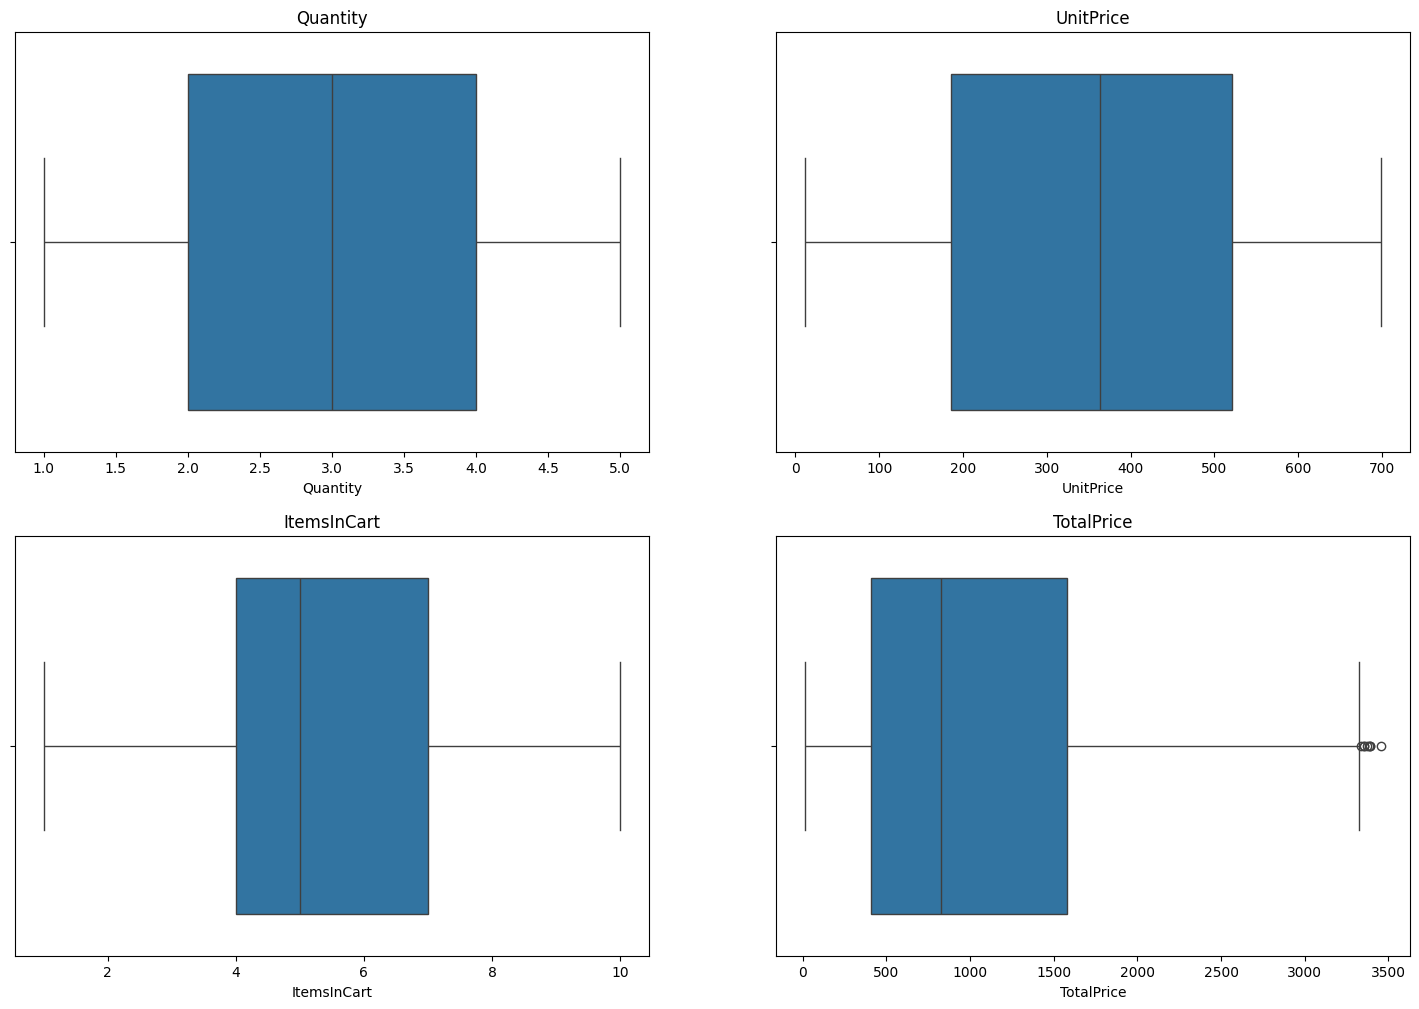

In [123]:
num_cols = df.select_dtypes(include=['float64',"int64"]).columns

fig = plt.figure(figsize=(18,12))
for i in range(len(num_cols)):
    ax = fig.add_subplot(2,2,i+1)
    sns.boxplot(x = df[num_cols[i]],ax=ax)
    ax.set_title(num_cols[i])
plt.show()
# TotalPrice has outlier values

In [124]:
q1 = df['TotalPrice'].quantile(0.25)
q3 = df['TotalPrice'].quantile(0.75)
IQR = q3 - q1
upper_limit = q3 + 1.5 * IQR
lower_limit = q1 - 1.5 * IQR

outlier_count = (df['TotalPrice'] > upper_limit).sum()
print(f"Total outlier in TotalPrice column: {outlier_count}")

Total outlier in TotalPrice column: 8


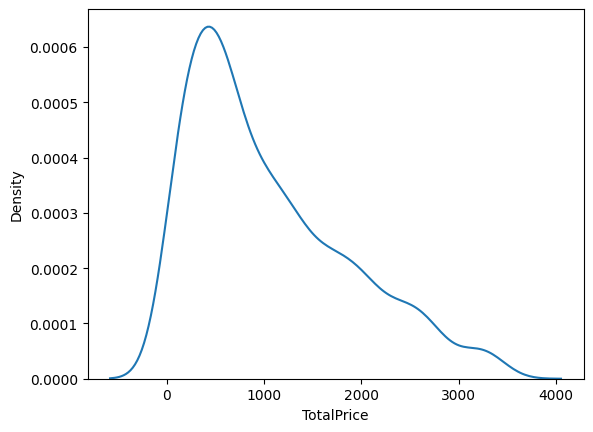

In [125]:
# Checking Skewness

sns.kdeplot(df['TotalPrice'])
plt.show()
# Total Price is right skew (mean > median)

In [126]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5.000000000,570,928 Main St,Debit Card,Shipped,TRK37947903,7.000000000,SAVE10,Instagram,2853.100000000
1,ORD200001,2024-08-23,C75739,Phone,2.000000000,151,823 Main St,Online,Shipped,TRK91186779,3.000000000,SAVE10,Referral,302.700000000
2,ORD200002,2024-02-27,C81728,Tablet,5.000000000,550,512 Main St,Credit Card,Cancelled,TRK42903982,8.000000000,FREESHIP,Email,2753.400000000
3,ORD200003,2023-10-15,C33540,Chair,1.000000000,273,275 Main St,Debit Card,Returned,TRK62788070,5.000000000,SAVE10,Facebook,273.190000000
4,ORD200004,2025-05-08,C81840,Printer,4.000000000,626,668 Main St,Online,Delivered,TRK29241424,8.000000000,SAVE10,Email,2504.040000000


In [127]:
df["Product"].value_counts()

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

In [128]:
df['PaymentMethod'].value_counts()

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

In [129]:
df['OrderStatus'].value_counts()

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

In [130]:
# Correlation between Quantity vs Total Price

df['Quantity'].corr(df['TotalPrice'])
#  A moderate positive relationship.

np.float64(0.6152513633467074)

In [131]:
df.groupby("Product",observed=False).agg(
    Total_Quantity_Sold =("Quantity","sum"),
    Total_Sales_Sum = ("TotalPrice","sum"),
    AveragePrice = ("TotalPrice","mean")
).sort_values(by=['Total_Sales_Sum'],ascending=[False])

# Chair and Printer are the top-selling products by total sales.

,Total_Quantity_Sold,Total_Sales_Sum,AveragePrice
Product,,,
Chair,562.000000000,195620.110000000,1098.989382022
Printer,542.000000000,195612.610000000,1080.732651934
Laptop,535.000000000,192126.560000000,1110.558150289
Tablet,497.000000000,186568.950000000,1042.284636872
Monitor,480.000000000,175651.410000000,1077.616012270
Desk,508.000000000,167459.930000000,985.058411765
Phone,411.000000000,151722.390000000,972.579423077


In [132]:
pd.set_option('display.float_format', lambda x: '%.9f' % x)


In [133]:
total_orders = df['OrderID'].count()
total_revenue = df['TotalPrice'].sum()
avg_order_value = df['TotalPrice'].mean()
highest_order_value = df['TotalPrice'].max()
lowest_order_value = df['TotalPrice'].min()

pd.DataFrame(index=["Total Orders","Total Revenue","Average Order Value","Highest Order Value","Lowest Order Value"],
            data=[total_orders,total_revenue,avg_order_value,highest_order_value,lowest_order_value],dtype='float64').rename(columns={0:"Values"})

,Values
Total Orders,1200.000000000
Total Revenue,1264761.960000000
Average Order Value,1053.968300000
Highest Order Value,3456.400000000
Lowest Order Value,11.390000000


In [134]:
df.groupby("OrderStatus",observed=False).agg(
    Order_Count = ("OrderStatus","count"),
    Total_Revenue = ("TotalPrice","sum"),
    Average_Order_Value = ("TotalPrice","mean")
)
# Cancelled orders have the highest total revenue among order statuses.

,Order_Count,Total_Revenue,Average_Order_Value
OrderStatus,,,
Cancelled,250,276396.210000000,1105.584840000
Delivered,231,242600.320000000,1050.217835498
Pending,237,256328.150000000,1081.553375527
Returned,247,243277.700000000,984.929959514
Shipped,235,246159.580000000,1047.487574468


In [135]:
df.groupby("PaymentMethod",observed=False).agg(
    Order_Count = ("PaymentMethod","count"),
    Total_Revenue = ("TotalPrice","sum"),
    Average_Order_Value = ("TotalPrice","mean")
)

,Order_Count,Total_Revenue,Average_Order_Value
PaymentMethod,,,
Cash,246,259786.290000000,1056.041829268
Credit Card,234,263847.630000000,1127.553974359
Debit Card,232,232361.180000000,1001.556810345
Gift Card,230,246323.920000000,1070.973565217
Online,258,262442.940000000,1017.220697674
